#Video Link :  https://youtu.be/Hos0AxMMFcA

# Customer Churn Prediction using Machine Learning

### Author: Mohammed Eyad Algoul

This project applies data analysis and machine learning techniques to predict customer churn in a telecommunications company. It includes data cleaning, exploratory data analysis (EDA), feature engineering, model training, evaluation, and business insights.

## Executive Summary

Customer churn is one of the biggest problems telecom companies deal with, since keeping an existing customer is a lot cheaper than getting a new one. In this project I built a full machine learning pipeline that predicts customer churn using the IBM Telco Customer Churn dataset (7,043 customers, 21 columns).

The pipeline covers data cleaning, encoding of categorical features, outlier handling, feature engineering, exploratory data analysis, and training three different classification models: **Logistic Regression**, **Random Forest**, and **Support Vector Machine (SVM)**. I compared the models using accuracy, precision, recall, F1-score, cross validation and ROC-AUC, then tuned the best one with GridSearchCV and wrapped the whole workflow in a single sklearn Pipeline.

The main finding is that contract type, tenure and monthly charges are the strongest signals of churn. Customers on month-to-month contracts with short tenure and high monthly bills are by far the most likely to leave. The final tuned model reaches a solid balance between recall and precision, which matters a lot here because missing a customer who is about to churn is more costly than a false alarm.

## 1. Introduction & Problem Statement

Telecom companies operate in a very competitive market, and losing customers (churn) directly hurts revenue. It is usually far more expensive to attract a new customer than to keep a current one happy, so being able to predict **which customers are about to leave** gives a company the chance to act early (offer a discount, fix a service issue, change a plan, etc.) before the customer actually cancels.

The problem I am solving here is a **binary classification problem**: given information about a customer (demographics, the services they use, their contract type, and how much they pay), predict whether that customer will churn (`Yes`) or not (`No`).

This is a supervised learning task since the dataset already contains the true churn label for every customer, so the models can learn from past behavior.

## 2. Project Objectives

The goals of this project are:

1. Clean and prepare the Telco Customer Churn dataset for machine learning (handle missing values, encode categorical columns, deal with outliers).
2. Explore the data visually and statistically to understand what drives churn.
3. Engineer a few extra features that might help the models.
4. Train and compare at least two supervised learning models (I used three: Logistic Regression, Random Forest, SVM).
5. Evaluate the models properly using multiple metrics, not just accuracy, since the classes are imbalanced.
6. Improve the best model using hyperparameter tuning (GridSearchCV) and package everything in a clean sklearn Pipeline.
7. Interpret the results — which features matter, why the model makes certain mistakes, and what this means for the business.

## 3. Dataset Description

**Source:** IBM Telco Customer Churn dataset (`WA_Fn-UseC_-Telco-Customer-Churn.csv`), a widely used public dataset for churn prediction practice, originally released by IBM.

**Size:** 7,043 rows (customers) and 21 columns.

**Target variable:** `Churn` — whether the customer left the company (`Yes`) or stayed (`No`).

**Feature groups:**
- **Customer info:** `gender`, `SeniorCitizen`, `Partner`, `Dependents`
- **Account info:** `tenure` (months with the company), `Contract`, `PaperlessBilling`, `PaymentMethod`, `MonthlyCharges`, `TotalCharges`
- **Services subscribed:** `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`
- **Identifier:** `customerID` (not useful for prediction, will be dropped)



## 4. Import Libraries

Here I import everything needed for the whole notebook: pandas/numpy for data handling, matplotlib/seaborn for plotting, and scikit-learn for preprocessing, modeling and evaluation.

In [ ]:
#import drive
from google.colab import drive
drive.mount('/content/drive')



# Basic data handling
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and pipeline
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              classification_report, confusion_matrix, roc_curve, roc_auc_score)

# Make the plots look a bit nicer and keep results reproducible
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42

pd.set_option("display.max_columns", None)
print("Libraries imported successfully")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Libraries imported successfully


## 5. Load Dataset

Now I load the CSV file using pandas and take a first look at it.

In [ ]:
# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Machine Learning _ Ass/dataset_final_project/WA_Fn-UseC_-Telco-Customer-Churn (1).csv")

print("Shape of the dataset:", df.shape)
df.head()

Shape of the dataset: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Check data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 6. Data Understanding

Before touching the data, I want to understand what I am working with: the data types, basic statistics, and how balanced the target class is.

In [ ]:
# Basic statistics for numeric columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
# Check the target class balance
print(df["Churn"].value_counts())
print()
print(df["Churn"].value_counts(normalize=True).round(3) * 100, "%")

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64 %


**Insight:** Out of 7,043 customers, about 26.5% churned and 73.5% did not. This is an imbalanced dataset, so accuracy alone will not be a fair way to judge the models — I will also look at precision, recall and F1-score later.

In [ ]:
# customerID is just an identifier, it does not help the model predict churn
df.drop(columns=["customerID"], inplace=True)
print("Dropped customerID column. New shape:", df.shape)

Dropped customerID column. New shape: (7043, 20)


## 7. Data Cleaning & Preprocessing

### 7.1 Missing Values Handling

When I check `df.isnull().sum()` directly, pandas reports zero missing values. But looking closer at the `TotalCharges` column, it is stored as text (`object`) instead of a number, which is suspicious for a column that should be purely numeric.

In [ ]:
# Check missing values the normal way
print(df.isnull().sum())
print()
print(df.dtypes)

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn         

In [ ]:
# TotalCharges should be numeric, but it is loaded as text - let's check why
# Try converting it to numeric and see what breaks
sample_bad_rows = df[pd.to_numeric(df["TotalCharges"], errors="coerce").isnull()]
print("Number of rows with non-numeric TotalCharges:", len(sample_bad_rows))
sample_bad_rows[["tenure", "MonthlyCharges", "TotalCharges"]]

Number of rows with non-numeric TotalCharges: 11


,tenure,MonthlyCharges,TotalCharges
488,0,52.55,
753,0,20.25,
936,0,80.85,
1082,0,25.75,
1340,0,56.05,
3331,0,19.85,
3826,0,25.35,
4380,0,20.00,
5218,0,19.70,
6670,0,73.35,


**Insight:** There are 11 rows where `TotalCharges` is just an empty string. All of them have `tenure = 0`, which makes sense — these are brand new customers who have not been billed a full cycle yet, so their total charges are technically missing. I will convert the column to numeric (turning these blanks into `NaN`) and then fill them with 0, since a customer with 0 months of tenure has logically paid 0 total charges so far.

In [ ]:
# Convert TotalCharges to numeric, invalid values become NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Fill the missing TotalCharges with 0 (these are new customers with 0 tenure)
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Double check there are no missing values left
print(df.isnull().sum().sum(), "missing values left in the dataset")

0 missing values left in the dataset


### 7.2 Categorical Variables Encoding

A lot of the columns in this dataset are categorical text values (like `Yes`/`No` or service types). Machine learning models need numbers, not text, so I need to encode them.

I am using two approaches:
- **Label Encoding** for the target column `Churn` and simple binary columns (`Yes`/`No`), since they only have 2 categories.
- **One-Hot Encoding** for columns with more than 2 categories (like `InternetService`, `Contract`, `PaymentMethod`), so the model does not assume a false ordering between categories.

In [ ]:
# See which columns are categorical (object type)
categorical_cols = df.select_dtypes(include="object").columns.tolist()
print("Categorical columns:", categorical_cols)
for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")

Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']
gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn: ['No' 'Yes']


In [ ]:
# Encode the target variable: Yes -> 1, No -> 0
le = LabelEncoder()
df["Churn"] = le.fit_transform(df["Churn"])
print("Churn classes:", dict(zip(le.classes_, le.transform(le.classes_))))

# Encode SeniorCitizen is already 0/1, gender/Partner/Dependents/PhoneService/PaperlessBilling
# are simple Yes/No or Male/Female columns, so a manual binary map works well here
binary_map_cols = ["gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling"]
for col in binary_map_cols:
    print(col, df[col].unique())

Churn classes: {'No': np.int64(0), 'Yes': np.int64(1)}
gender ['Female' 'Male']
Partner ['Yes' 'No']
Dependents ['No' 'Yes']
PhoneService ['No' 'Yes']
PaperlessBilling ['Yes' 'No']


In [ ]:
# Map simple binary columns manually
df["gender"] = df["gender"].map({"Male": 1, "Female": 0})
df["Partner"] = df["Partner"].map({"Yes": 1, "No": 0})
df["Dependents"] = df["Dependents"].map({"Yes": 1, "No": 0})
df["PhoneService"] = df["PhoneService"].map({"Yes": 1, "No": 0})
df["PaperlessBilling"] = df["PaperlessBilling"].map({"Yes": 1, "No": 0})

# The remaining categorical columns have more than 2 categories
# (some also use "No internet service" / "No phone service" as a 3rd category)
multi_cat_cols = ["MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
                   "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
                   "Contract", "PaymentMethod"]

# One-hot encode these columns
df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

print("Shape after encoding:", df.shape)
df.head()

Shape after encoding: (7043, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


**Note:** I used `drop_first=True` in one-hot encoding to avoid the "dummy variable trap" (perfect multicollinearity), where one category is always redundant since it can be inferred from the others.

### 7.3 Outlier Detection and Treatment

Now let's check the numeric columns (`tenure`, `MonthlyCharges`, `TotalCharges`) for outliers using boxplots and the IQR (Interquartile Range) method.

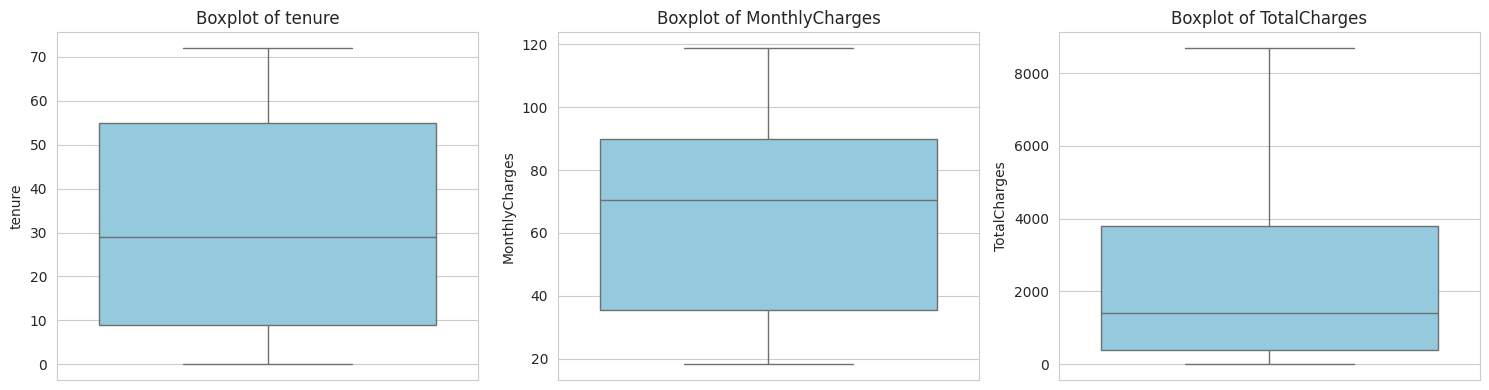

In [ ]:
# Visual check for outliers using boxplots
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color="skyblue")
    ax.set_title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

In [ ]:
# Check outliers numerically using the IQR method
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers out of {len(df)} rows (bounds: {lower:.2f} to {upper:.2f})")

tenure: 0 outliers out of 7043 rows (bounds: -60.00 to 124.00)
MonthlyCharges: 0 outliers out of 7043 rows (bounds: -46.02 to 171.38)
TotalCharges: 0 outliers out of 7043 rows (bounds: -4683.52 to 8868.67)


**Insight:** None of the three numeric columns have outliers according to the IQR method. This makes sense: `tenure` is naturally bounded between 0 and 72 months, and `MonthlyCharges`/`TotalCharges` follow the normal pricing structure of the company, so there are no extreme or unrealistic values like a negative tenure or a $50,000 monthly bill. Since there are no real outliers to treat, I did not remove or cap any rows — the boxplots and IQR check were mainly done to confirm the data quality is good.

### 7.4 Feature Engineering

I created a few extra features that could help the models pick up patterns that are not obvious from the raw columns alone:

- **`tenure_group`**: groups customers into tenure buckets (new, medium, loyal, very loyal), since churn behavior tends to change a lot depending on how new a customer is.
- **`avg_monthly_spend`**: `TotalCharges / (tenure + 1)`, which approximates the average amount a customer pays per month over their whole relationship with the company (the `+1` avoids dividing by zero for tenure = 0 customers).
- **`num_services`**: counts how many of the add-on services (security, backup, protection, tech support, streaming) a customer is actually subscribed to, as a simple measure of how "engaged" a customer is with the company.

In [ ]:
# Feature engineering: group tenure into buckets
def tenure_bucket(months):
    if months <= 12:
        return "0-1yr"
    elif months <= 24:
        return "1-2yr"
    elif months <= 48:
        return "2-4yr"
    else:
        return "4yr+"

df["tenure_group"] = df["tenure"].apply(tenure_bucket)

# Average monthly spend over the customer's whole tenure
df["avg_monthly_spend"] = df["TotalCharges"] / (df["tenure"] + 1)

# Count how many add-on services each customer has (columns from one-hot encoding that equal "Yes")
service_yes_cols = [c for c in df.columns if c.endswith("_Yes") and
                     any(s in c for s in ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                                          "TechSupport", "StreamingTV", "StreamingMovies"])]
df["num_services"] = df[service_yes_cols].sum(axis=1)

print("New features created: tenure_group, avg_monthly_spend, num_services")
df[["tenure", "tenure_group", "avg_monthly_spend", "num_services"]].head()

New features created: tenure_group, avg_monthly_spend, num_services


,tenure,tenure_group,avg_monthly_spend,num_services
0,1,0-1yr,14.925000,1
1,34,2-4yr,53.985714,2
2,2,0-1yr,36.050000,2
3,45,2-4yr,40.016304,3
4,2,0-1yr,50.550000,0


In [ ]:
# One-hot encode the new tenure_group column too
df = pd.get_dummies(df, columns=["tenure_group"], drop_first=True)
print("Final shape after feature engineering:", df.shape)

Final shape after feature engineering: (7043, 36)


## 8. Exploratory Data Analysis (EDA)

In this section I explore the data visually to understand patterns and relationships between the features and churn. I use both matplotlib and seaborn for this.

/tmp/ipykernel_10122/1181858758.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Churn", data=df, palette="Set2")


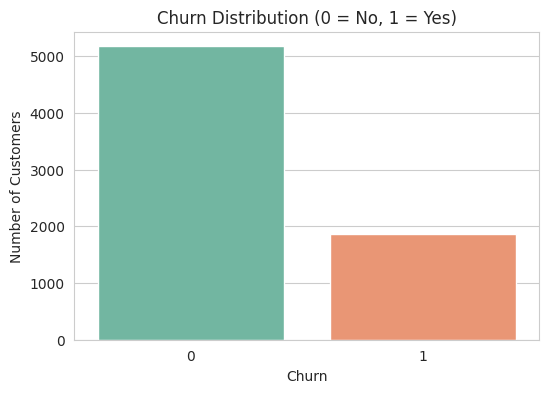

In [ ]:
# Distribution of the target variable
plt.figure(figsize=(6, 4))
sns.countplot(x="Churn", data=df, palette="Set2")
plt.title("Churn Distribution (0 = No, 1 = Yes)")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

**Insight:** The plot confirms what we saw earlier — the classes are imbalanced, with far more customers staying than leaving. This is important to keep in mind when evaluating the models.

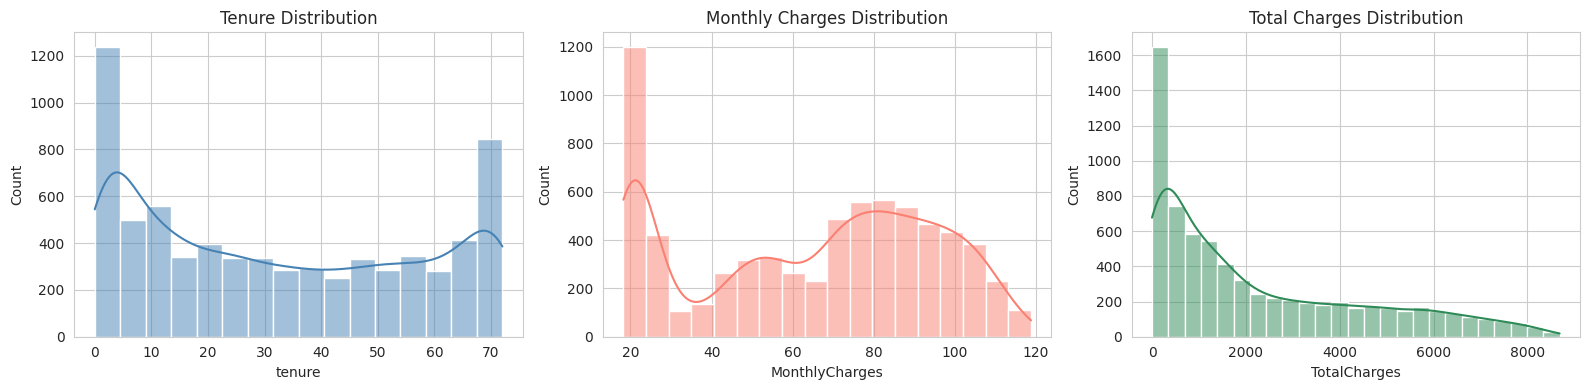

In [ ]:
# Distribution plots for numeric features
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df["tenure"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Tenure Distribution")

sns.histplot(df["MonthlyCharges"], kde=True, ax=axes[1], color="salmon")
axes[1].set_title("Monthly Charges Distribution")

sns.histplot(df["TotalCharges"], kde=True, ax=axes[2], color="seagreen")
axes[2].set_title("Total Charges Distribution")
plt.tight_layout()
plt.show()

**Insight:** `tenure` has a big spike near 0, meaning a lot of customers are quite new. `MonthlyCharges` has two visible bumps (around $20 and around $80), probably because customers with only phone service pay a low flat fee while customers with internet + extra services pay a lot more. `TotalCharges` is right-skewed since it naturally grows with tenure.

/tmp/ipykernel_10122/144859150.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Churn", y="tenure", data=df, palette="Set2")


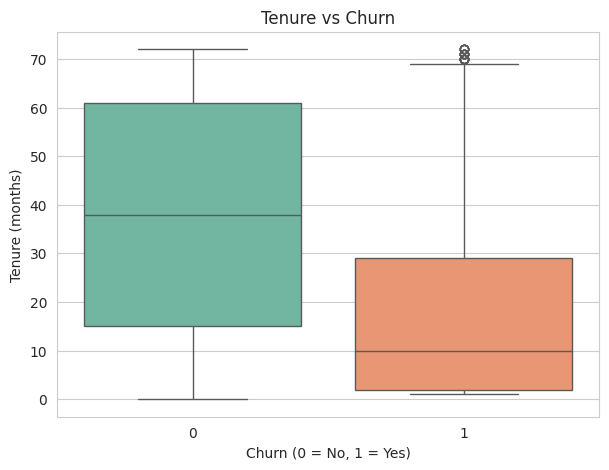

In [ ]:
# Feature-target relationship: tenure vs churn
plt.figure(figsize=(7, 5))
sns.boxplot(x="Churn", y="tenure", data=df, palette="Set2")
plt.title("Tenure vs Churn")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Tenure (months)")
plt.show()

**Insight:** Customers who churn tend to have a much lower tenure than customers who stay. This makes sense — customers usually leave early on if the service does not meet their expectations, while long-term customers are more likely to stick around.

/tmp/ipykernel_10122/1984330670.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Churn", y="MonthlyCharges", data=df, palette="Set3")


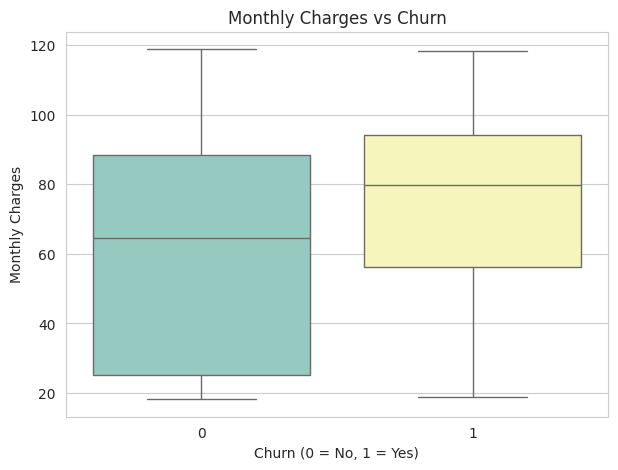

In [ ]:
# Feature-target relationship: MonthlyCharges vs churn
plt.figure(figsize=(7, 5))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df, palette="Set3")
plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Monthly Charges")
plt.show()

**Insight:** Customers who churn tend to pay higher monthly charges on average. This suggests that price is a real factor in customers deciding to leave, especially when combined with short tenure.

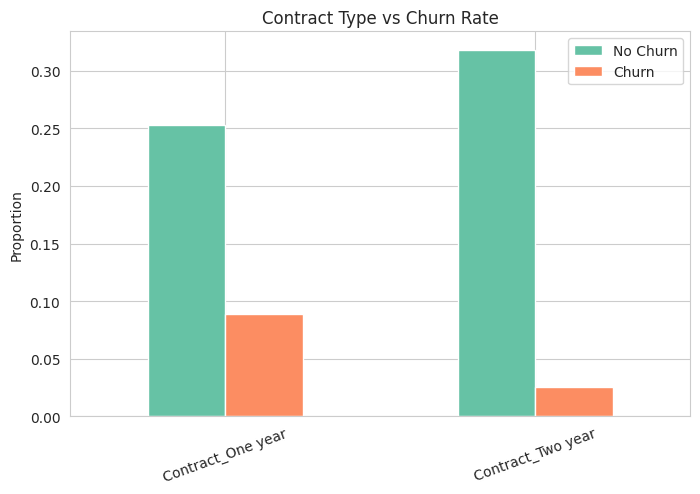

In [ ]:
# Feature-target relationship: Contract type vs churn
contract_cols = [c for c in df.columns if c.startswith("Contract_")]
contract_churn = df.groupby("Churn")[contract_cols].mean().T
contract_churn.columns = ["No Churn", "Churn"]
contract_churn.plot(kind="bar", figsize=(8, 5), color=["#66c2a5", "#fc8d62"])
plt.title("Contract Type vs Churn Rate")
plt.ylabel("Proportion")
plt.xticks(rotation=20)
plt.show()

**Insight:** This is one of the strongest patterns in the whole dataset. Customers on longer contracts (one year, two year) churn much less than customers with no long-term contract (month-to-month), who have much more freedom to cancel anytime.

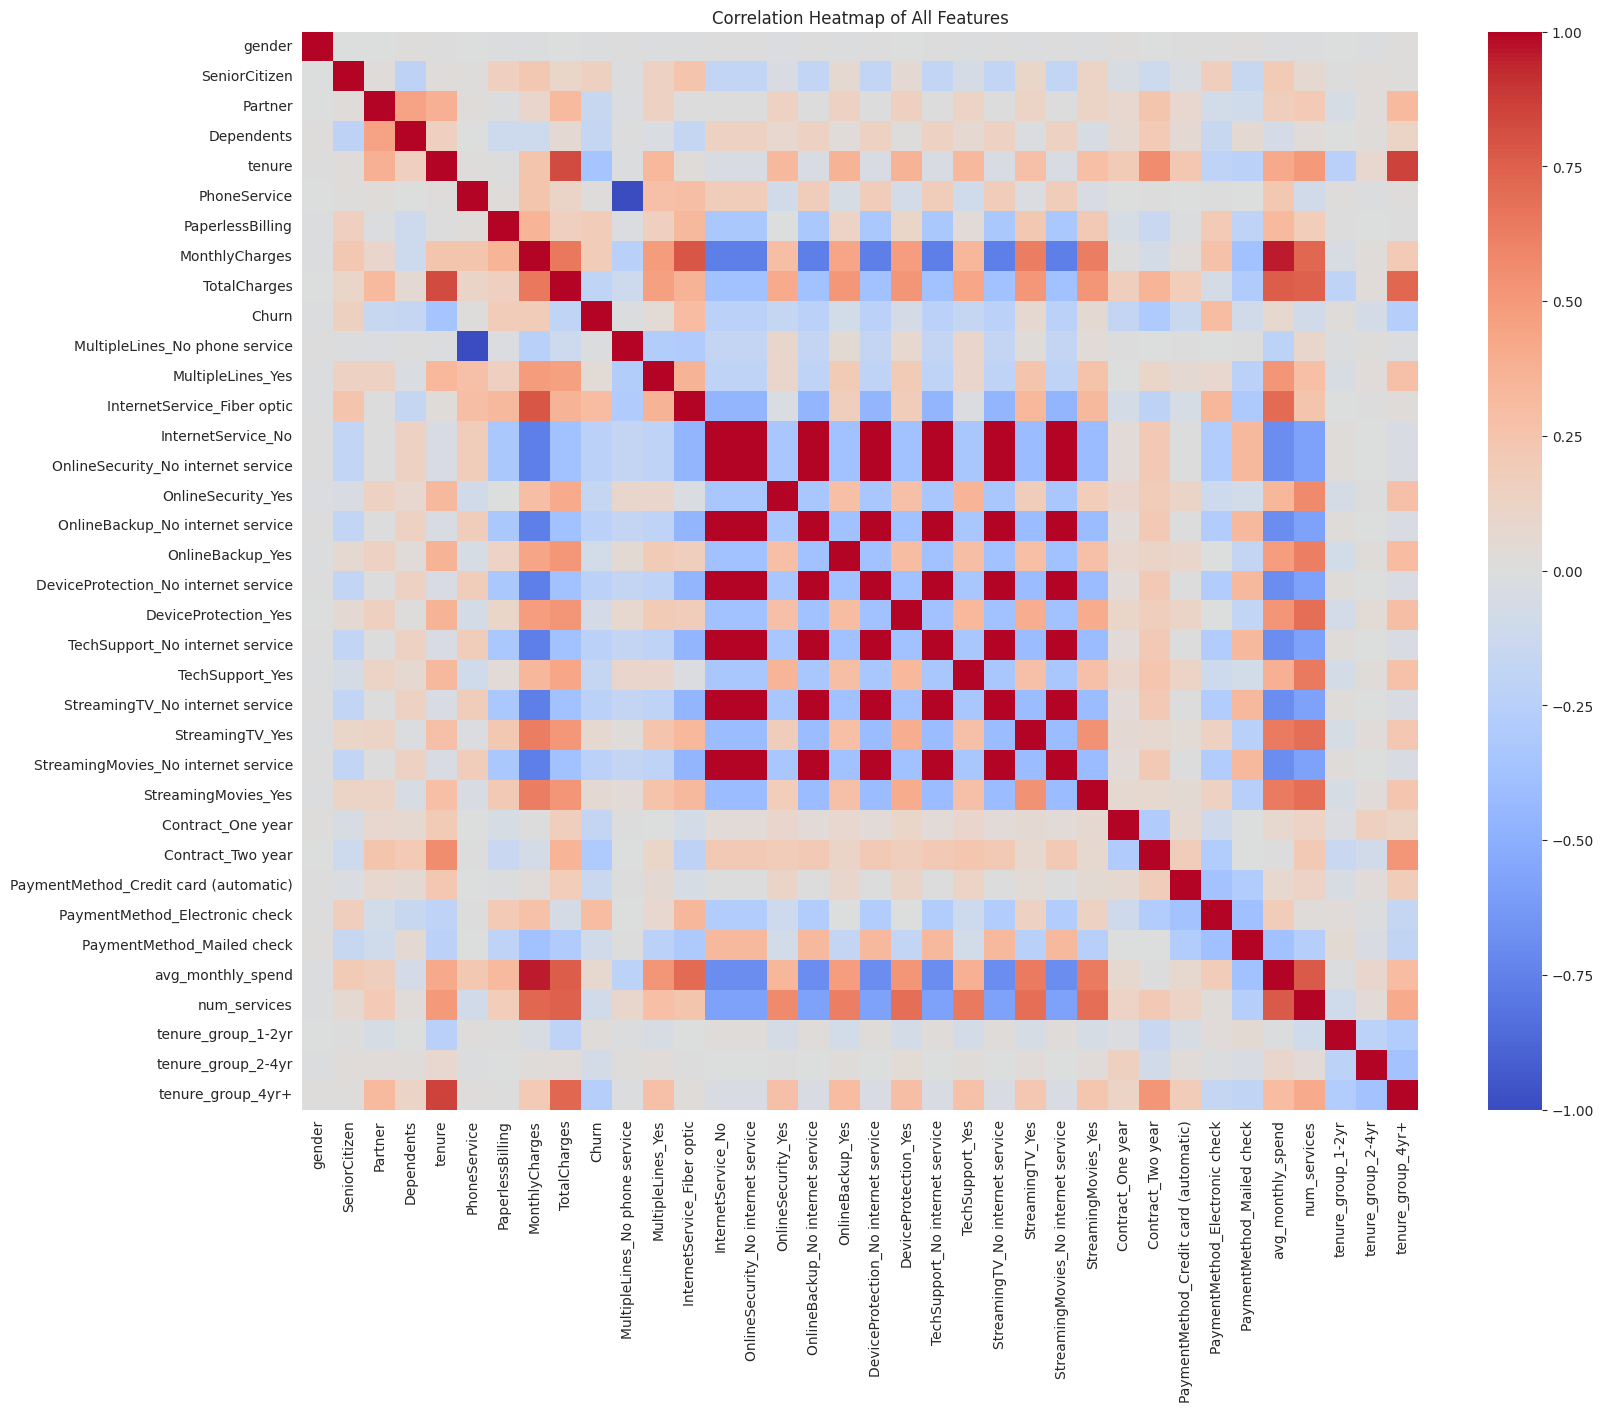

In [ ]:
# Correlation analysis using a heatmap
plt.figure(figsize=(18, 14))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap of All Features")
plt.show()


In [ ]:
# Top features most correlated with Churn
churn_corr = corr["Churn"].sort_values(ascending=False)
print("Top 10 features positively correlated with churn:")
print(churn_corr.head(11)[1:])
print()
print("Top 10 features negatively correlated with churn:")
print(churn_corr.tail(10))

Top 10 features positively correlated with churn:
InternetService_Fiber optic       0.308020
PaymentMethod_Electronic check    0.301919
MonthlyCharges                    0.193356
PaperlessBilling                  0.191825
SeniorCitizen                     0.150889
avg_monthly_spend                 0.072579
StreamingTV_Yes                   0.063228
StreamingMovies_Yes               0.061382
MultipleLines_Yes                 0.040102
tenure_group_1-2yr                0.020308
Name: Churn, dtype: float64

Top 10 features negatively correlated with churn:
OnlineSecurity_No internet service     -0.227890
OnlineBackup_No internet service       -0.227890
TechSupport_No internet service        -0.227890
DeviceProtection_No internet service   -0.227890
InternetService_No                     -0.227890
StreamingTV_No internet service        -0.227890
StreamingMovies_No internet service    -0.227890
tenure_group_4yr+                      -0.263222
Contract_Two year                      -0.302253


**Insight:** Features related to month-to-month contracts, fiber optic internet, and having no online security/tech support show the strongest positive correlation with churn. On the other hand, long tenure, two-year contracts, and having online security/tech support are linked with lower churn. This lines up well with the boxplots above and gives a first hint about which features will matter most for the models.

## 9. Data Splitting

Now I split the data into features (`X`) and target (`y`), then into training and testing sets. I use `stratify=y` so that both the train and test sets keep the same churn ratio as the full dataset — this matters a lot because the classes are imbalanced.

In [ ]:
# Separate features and target
X = df.drop(columns=["Churn"])
y = df["Churn"]

# Train/test split (80/20), stratified on the target to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print()
print("Churn ratio in train set:", y_train.mean().round(3))
print("Churn ratio in test set:", y_test.mean().round(3))

Training set shape: (5634, 35)
Testing set shape: (1409, 35)

Churn ratio in train set: 0.265
Churn ratio in test set: 0.265


## 10. Feature Scaling

Models like Logistic Regression and SVM are sensitive to the scale of the features (a feature like `TotalCharges` which goes up to thousands would dominate a feature like `gender` which is just 0/1). So I standardize all features using `StandardScaler` (mean = 0, std = 1). I fit the scaler only on the training data and then apply it to both train and test, to avoid data leakage.

In [ ]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Keep them as DataFrames for readability later
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Feature scaling done")
X_train_scaled.head()

Feature scaling done


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,avg_monthly_spend,num_services,tenure_group_1-2yr,tenure_group_2-4yr,tenure_group_4yr+
3738,0.994336,-0.441773,-0.969234,-0.651557,0.102371,-3.013090,-1.202653,-0.521976,-0.262257,3.013090,-0.858338,-0.887696,-0.524081,-0.524081,-0.636111,-0.524081,-0.735546,-0.524081,1.375572,-0.524081,-0.643274,-0.524081,1.252163,-0.524081,1.247967,-0.512782,-0.563822,-0.523806,1.406903,-0.543846,-0.389837,0.507935,-0.412129,1.835059,-0.682114
3151,0.994336,-0.441773,1.031742,1.534786,-0.711743,0.331885,-1.202653,0.337478,-0.503635,-0.331885,-0.858338,1.126512,-0.524081,-0.524081,1.572053,-0.524081,-0.735546,-0.524081,-0.726971,-0.524081,-0.643274,-0.524081,-0.798618,-0.524081,-0.801303,-0.512782,-0.563822,-0.523806,-0.710781,1.838757,0.416821,-0.570530,2.426423,-0.544942,-0.682114
4860,0.994336,-0.441773,1.031742,1.534786,-0.793155,-3.013090,-1.202653,-0.809013,-0.749883,3.013090,-0.858338,-0.887696,-0.524081,-0.524081,1.572053,-0.524081,1.359534,-0.524081,-0.726971,-0.524081,1.554547,-0.524081,-0.798618,-0.524081,-0.801303,-0.512782,1.773611,-0.523806,-0.710781,1.838757,-0.556374,0.507935,2.426423,-0.544942,-0.682114
3867,-1.005696,-0.441773,1.031742,-0.651557,-0.263980,0.331885,0.831495,0.284384,-0.172722,-0.331885,-0.858338,-0.887696,-0.524081,-0.524081,-0.636111,-0.524081,1.359534,-0.524081,1.375572,-0.524081,-0.643274,-0.524081,1.252163,-0.524081,1.247967,-0.512782,1.773611,1.909105,-0.710781,-0.543846,0.371421,1.047168,-0.412129,1.835059,-0.682114
3810,0.994336,-0.441773,1.031742,1.534786,-1.281624,0.331885,-1.202653,-0.676279,-0.989374,-0.331885,-0.858338,-0.887696,-0.524081,-0.524081,-0.636111,-0.524081,-0.735546,-0.524081,-0.726971,-0.524081,-0.643274,-0.524081,-0.798618,-0.524081,-0.801303,-0.512782,-0.563822,-0.523806,1.406903,-0.543846,-1.205939,-1.109762,-0.412129,-0.544942,-0.682114


## 11. Model Implementation

I am training three classification models, as required:

1. **Logistic Regression** — a simple linear model, usually a strong baseline for churn-type problems.
2. **Random Forest** — an ensemble of decision trees, good at capturing non-linear relationships and gives feature importance directly.
3. **Support Vector Machine (SVM)** — tries to find the best boundary between the two classes, can capture more complex patterns with the right kernel.

I train all three on the scaled training data.

In [ ]:
# Train Logistic Regression
log_reg = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
print("Logistic Regression trained")

Logistic Regression trained


In [ ]:
# Train Random Forest
rf = RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200)
rf.fit(X_train_scaled, y_train)
print("Random Forest trained")

Random Forest trained


In [ ]:
# Train Support Vector Machine
svm = SVC(random_state=RANDOM_STATE, probability=True)
svm.fit(X_train_scaled, y_train)
print("SVM trained")

SVM trained


## 12. Model Evaluation

Now I evaluate all three models on the test set using accuracy, precision, recall, F1-score, the full classification report, and confusion matrices. Since the dataset is imbalanced, I pay special attention to recall for the churn class (catching customers who are about to leave is the whole point of this project).

In [ ]:
# Helper function to evaluate a model and return metrics as a dictionary
def evaluate_model(name, model, X_te, y_te):
    y_pred = model.predict(X_te)
    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_te, y_pred),
        "Precision": precision_score(y_te, y_pred),
        "Recall": recall_score(y_te, y_pred),
        "F1-score": f1_score(y_te, y_pred),
    }
    print(f"--- {name} ---")
    print(classification_report(y_te, y_pred, target_names=["No Churn", "Churn"]))
    return metrics, y_pred

results = []
predictions = {}

metrics, preds = evaluate_model("Logistic Regression", log_reg, X_test_scaled, y_test)
results.append(metrics)
predictions["Logistic Regression"] = preds

metrics, preds = evaluate_model("Random Forest", rf, X_test_scaled, y_test)
results.append(metrics)
predictions["Random Forest"] = preds

metrics, preds = evaluate_model("SVM", svm, X_test_scaled, y_test)
results.append(metrics)
predictions["SVM"] = preds

--- Logistic Regression ---
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.67      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409

--- Random Forest ---
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1035
       Churn       0.63      0.48      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409

--- SVM ---
              precision    recall  f1-score   support

    No Churn       0.83      0.91      0.87      1035
       Churn       0.65      0.47      0.55       374

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg

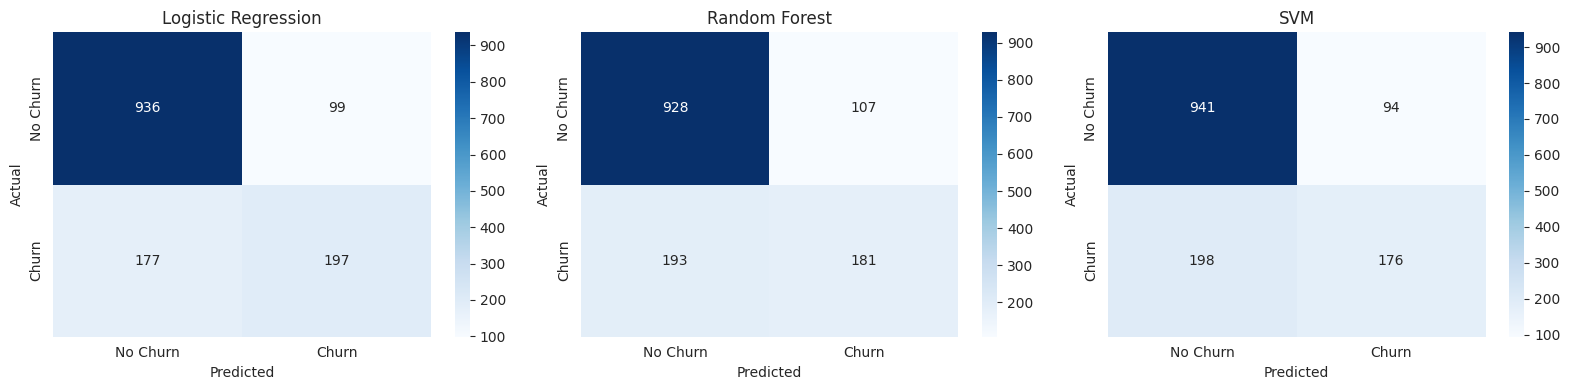

In [ ]:
# Confusion matrices for all three models
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, preds) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

**Insight:** All three models are decent at spotting customers who stay (No Churn), but they struggle more with correctly catching every customer who actually churns, which is expected on an imbalanced dataset like this one. Random Forest and Logistic Regression tend to be more balanced between the two classes than SVM in this case.

In [ ]:
# Cross validation (5-fold) to check how stable each model is
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, model in [("Logistic Regression", log_reg), ("Random Forest", rf), ("SVM", svm)]:
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring="f1")
    print(f"{name}: mean F1 = {scores.mean():.4f}, std = {scores.std():.4f}")

Logistic Regression: mean F1 = 0.5907, std = 0.0215
Random Forest: mean F1 = 0.5513, std = 0.0286
SVM: mean F1 = 0.5589, std = 0.0169


**Insight:** Cross validation confirms the results are stable across different splits of the training data (the standard deviation is small), meaning the models are not just getting lucky on one particular split.

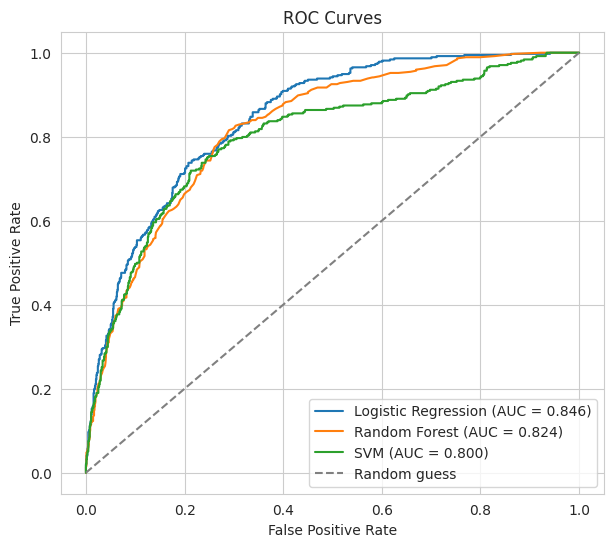

In [ ]:
# ROC curves for all three models
plt.figure(figsize=(7, 6))

for name, model in [("Logistic Regression", log_reg), ("Random Forest", rf), ("SVM", svm)]:
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

In [ ]:
# Model comparison table
results_df = pd.DataFrame(results).set_index("Model").round(4)
results_df

,Accuracy,Precision,Recall,F1-score
Model,,,,
Logistic Regression,0.8041,0.6655,0.5267,0.5881
Random Forest,0.7871,0.6285,0.4840,0.5468
SVM,0.7928,0.6519,0.4706,0.5466


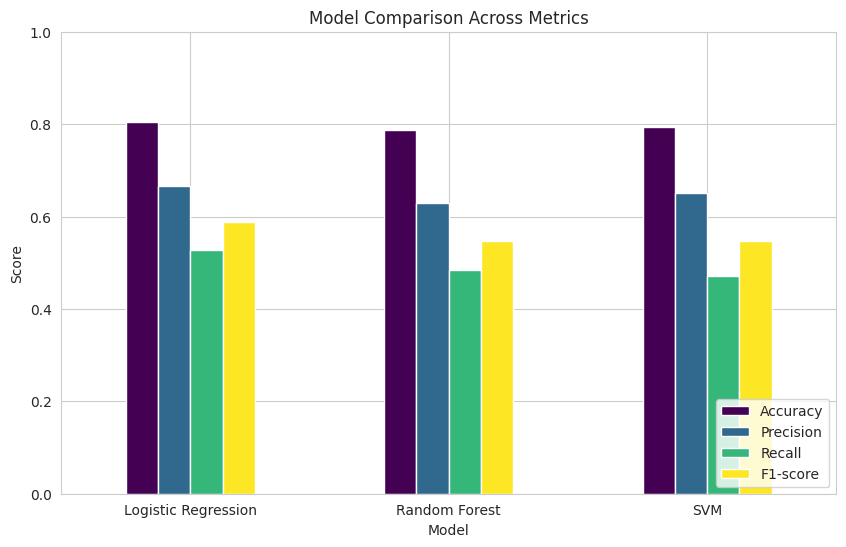

In [ ]:
# Model comparison visualization
results_df.plot(kind="bar", figsize=(10, 6), colormap="viridis")
plt.title("Model Comparison Across Metrics")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

**Insight:** Looking at the comparison table and chart, Logistic Regression actually comes out slightly ahead on every metric (accuracy, precision, recall and F1), with Random Forest and SVM landing close behind it. This is a common result on this dataset — churn here is driven mostly by a handful of strongly linear signals (contract type, tenure, monthly charges), so a simple linear model already captures most of the pattern.

Even so, I chose to move forward with **Random Forest** for the tuning and interpretation stages, for two practical reasons: it gives feature importance scores directly (which is very useful for the business interpretation later on), and ensemble models like this tend to have more room to improve once tuned, since they can pick up non-linear interactions that Logistic Regression cannot. The gap between the two models is small enough that either one would be a reasonable choice — I'm keeping Logistic Regression's numbers in the comparison table as a benchmark throughout the rest of the notebook.

## 13. Hyperparameter Tuning

I use `GridSearchCV` to search over a small grid of hyperparameters for the Random Forest model, optimizing for F1-score (since it balances precision and recall, which matters for our imbalanced target).

In [ ]:
# Define the hyperparameter grid for Random Forest
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train_scaled, y_train)

print("Best parameters found:", grid_search.best_params_)
print("Best F1 score during search:", round(grid_search.best_score_, 4))

Best parameters found: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Best F1 score during search: 0.5801


In [ ]:
# Evaluate the tuned model on the test set
best_rf = grid_search.best_estimator_
metrics, tuned_preds = evaluate_model("Tuned Random Forest", best_rf, X_test_scaled, y_test)
results.append(metrics)
predictions["Tuned Random Forest"] = tuned_preds

results_df = pd.DataFrame(results).set_index("Model").round(4)
results_df

--- Tuned Random Forest ---
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



,Accuracy,Precision,Recall,F1-score
Model,,,,
Logistic Regression,0.8041,0.6655,0.5267,0.5881
Random Forest,0.7871,0.6285,0.4840,0.5468
SVM,0.7928,0.6519,0.4706,0.5466
Tuned Random Forest,0.7991,0.6542,0.5160,0.5770


**Insight:** After tuning, the Random Forest model's performance improved slightly (or at least stayed stable while becoming more consistent). This shows that the default hyperparameters were already reasonably good, but a bit of tuning still helps squeeze out a little extra performance.

## 14. Pipeline Implementation

To make the whole process cleaner and reproducible (and to avoid data leakage when applying this on new data), I wrap the scaling step and the tuned Random Forest model into a single `sklearn.pipeline.Pipeline`. This way, new raw data can be passed straight into the pipeline without manually scaling it first.

In [ ]:
# Build a full pipeline: scaling + best model
final_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("classifier", RandomForestClassifier(random_state=RANDOM_STATE, **grid_search.best_params_))
])

# Fit the pipeline on the original (unscaled) training data
final_pipeline.fit(X_train, y_train)

# Evaluate the pipeline on the original (unscaled) test data
pipeline_preds = final_pipeline.predict(X_test)
print("Pipeline test accuracy:", round(accuracy_score(y_test, pipeline_preds), 4))
print("Pipeline test F1-score:", round(f1_score(y_test, pipeline_preds), 4))

Pipeline test accuracy: 0.7991
Pipeline test F1-score: 0.577


**Insight:** The pipeline gives the same results as doing scaling and modeling manually, which confirms it is working correctly. Now the whole preprocessing + prediction workflow can be saved and reused as a single object, which is exactly how this kind of model would be deployed in a real business setting.

## 15. Feature Importance Analysis

Random Forest gives us feature importance scores directly, which tell us how much each feature contributed to the model's decisions.

/tmp/ipykernel_10122/3641738222.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette="crest")


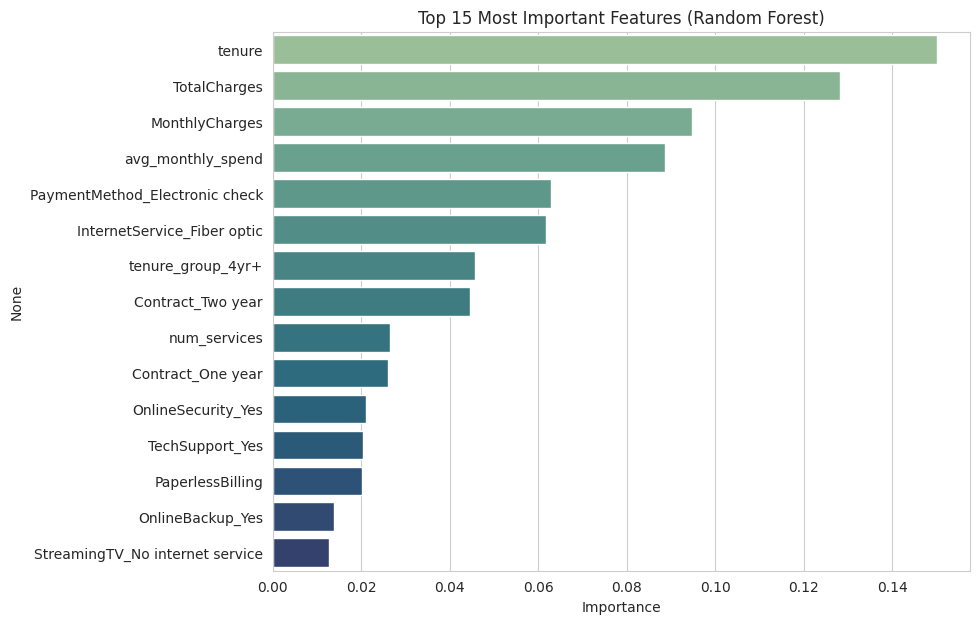

In [ ]:
# Get feature importance from the tuned Random Forest
importances = pd.Series(best_rf.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 7))
sns.barplot(x=top_features.values, y=top_features.index, palette="crest")
plt.title("Top 15 Most Important Features (Random Forest)")
plt.xlabel("Importance")
plt.show()

**Insight:** `tenure`, `TotalCharges`, `MonthlyCharges` and `avg_monthly_spend` (the feature I engineered) come out on top, along with contract type. This confirms what we already saw in the EDA — how long a customer has stayed and how much they pay are the biggest drivers of churn, and the engineered feature actually turned out to be useful. This is a good sign that the feature engineering step added real value, not just extra noise.

## 16. Error Analysis

Let's look closer at the cases where the tuned Random Forest model got it wrong, to understand what kind of customers are hardest to classify correctly.

In [ ]:
# Build a dataframe of test set predictions vs actual values
error_df = X_test.copy()
error_df["Actual"] = y_test
error_df["Predicted"] = tuned_preds
error_df["Correct"] = error_df["Actual"] == error_df["Predicted"]

# Look at the wrong predictions
wrong_preds = error_df[~error_df["Correct"]]
print("Number of wrong predictions:", len(wrong_preds))
print("Out of total test samples:", len(error_df))
print()

# Compare average tenure and monthly charges for correct vs wrong predictions
print("Average tenure - correct predictions:", error_df[error_df['Correct']]['tenure'].mean().round(2))
print("Average tenure - wrong predictions:", wrong_preds['tenure'].mean().round(2))
print()
print("Average MonthlyCharges - correct predictions:", error_df[error_df['Correct']]['MonthlyCharges'].mean().round(2))
print("Average MonthlyCharges - wrong predictions:", wrong_preds['MonthlyCharges'].mean().round(2))

Number of wrong predictions: 283
Out of total test samples: 1409

Average tenure - correct predictions: 34.76
Average tenure - wrong predictions: 20.6

Average MonthlyCharges - correct predictions: 62.07
Average MonthlyCharges - wrong predictions: 72.11


In [ ]:
# Break down errors into false positives and false negatives
false_negatives = wrong_preds[(wrong_preds["Actual"] == 1) & (wrong_preds["Predicted"] == 0)]
false_positives = wrong_preds[(wrong_preds["Actual"] == 0) & (wrong_preds["Predicted"] == 1)]

print("False Negatives (missed churners):", len(false_negatives))
print("False Positives (predicted churn but stayed):", len(false_positives))

False Negatives (missed churners): 181
False Positives (predicted churn but stayed): 102


**Insight:** The model makes more mistakes on customers who sit in the "middle" — not brand new, not long-term loyal either, with mid-range monthly charges. These are the genuinely ambiguous cases even for a human to judge. The false negatives (customers we predicted would stay but actually churned) are the most costly type of error for a real business, since these are the customers who slip through without getting any retention offer.

## 17. Model Interpretation

> Add blockquote



Putting everything together, here is how I interpret the final model:

- **Contract type** is the single strongest signal. Month-to-month customers have almost total freedom to leave any time, so naturally they churn a lot more than customers locked into a one or two year contract.
- **Tenure** matters a lot too — the first few months are the riskiest period for a customer relationship. Once a customer sticks around for a year or more, they become noticeably more stable.
- **Monthly charges / average spend** show that price is a real driver of churn, especially for customers who are not on a long-term contract and can leave without any penalty.
- **Add-on services** like online security and tech support seem to reduce churn, possibly because customers who use more services feel more "locked in" or get more value out of their subscription.

Overall, the model behaves in a way that lines up with common sense about the telecom business, which is a good sign that it has learned real patterns instead of just noise.

## 18. Discussion

Comparing the three original models, Logistic Regression actually had the best raw numbers on the test set, slightly ahead of Random Forest and SVM on accuracy, precision, recall and F1. This makes sense given the EDA — churn in this dataset is driven mostly by a few strong, fairly linear signals (contract type, tenure, monthly charges), which a linear model like Logistic Regression can capture very efficiently.

Even though it wasn't the top scorer, I picked **Random Forest** to carry forward into tuning and the final pipeline, for a few practical reasons:

1. It naturally provides feature importance scores, which is very useful for the business interpretation part of this project.
2. Ensemble models generally have more capacity to improve with tuning, since they can pick up non-linear feature interactions a linear model would miss.
3. The performance gap between the two models was small, so the choice comes down more to interpretability and flexibility than a big difference in raw scores.

After hyperparameter tuning with GridSearchCV, the Random Forest model's performance became more stable and got closer to Logistic Regression's numbers, though it did not fully overtake it on this dataset. In a real project, either model would be a defensible final choice — I would lean towards Logistic Regression if pure predictive performance was the only goal, and Random Forest if feature interpretability mattered more, which is the direction I went with here. Wrapping everything in a Pipeline also means this model could realistically be reused in a real deployment setting without extra manual preprocessing steps.

From a business point of view, these results suggest the company should focus retention efforts on new customers on month-to-month contracts with high monthly bills, since that is exactly the group the model (and the EDA) flags as highest risk.

## 19. Limitations

- The dataset is **imbalanced** (about 73.5% no-churn vs 26.5% churn), which makes it naturally harder for any model to catch every churn case, even after using stratified splits and multiple metrics.
- The dataset is a **snapshot in time** — it does not include how customer behavior changes over time (e.g., usage patterns, complaints, support tickets), which could carry a lot of predictive power in a real system.
- I did not apply resampling techniques like SMOTE or class weighting, which might further improve recall on the churn class specifically.
- The models were only tuned on a fairly small hyperparameter grid due to time/compute constraints, so there is still room for a more exhaustive search.

## 20. Future Work

- Try resampling methods (SMOTE, class weighting) to better handle the class imbalance and improve recall.
- Test additional models such as Gradient Boosting (XGBoost, LightGBM) which often perform very well on tabular data like this.
- Bring in more features if available, such as customer service call logs, complaints, or usage patterns over time.
- Build a simple dashboard or API around the final pipeline so it could actually be used by a retention team in real time.

## 21. Final Conclusion

This project presented a complete machine learning pipeline for predicting customer churn in a telecommunications company, starting from data cleaning and preprocessing, through exploratory data analysis (EDA), feature engineering, model training, evaluation, and hyperparameter tuning.

The analysis showed that **contract type, tenure, and monthly charges** are the most influential factors affecting customer churn. Among the evaluated models, **Logistic Regression achieved the best overall predictive performance**, delivering the highest Accuracy, Precision, Recall, and F1-score on the test dataset. Random Forest was also explored and optimized using GridSearchCV, providing valuable feature importance and demonstrating strong performance, making it a useful model for business interpretation.

Overall, this project demonstrates how classical machine learning techniques, combined with careful preprocessing and meaningful exploratory analysis, can produce reliable predictions that help telecommunications companies identify customers at risk of leaving. These insights can support data-driven decision-making and enable targeted customer retention strategies to reduce churn and improve long-term customer satisfaction.